# 1. Quickstart

In [2]:
%pip install "jax[tpu]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.1/155.1 MB 5.8 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: libtpu
    Found existing installation: libtpu 0.0.21
    Uninstalling libtpu-0.0.21:
      Successfully uninstalled libtpu-0.0.21


## 1.1 JAX vs numpy
ok so JAX arrays can be used as a drop in replacement for np arrays (duck-typing!) - the difference is JAX arrays are **immutable!**

In [3]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


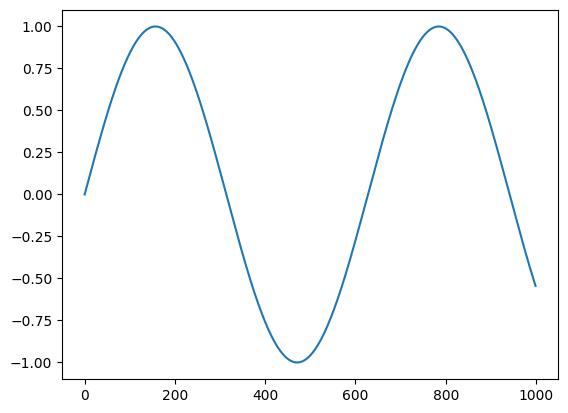

In [4]:
# makin a jax array
jax_arr = jnp.linspace(0, 10, 1000)
plt.plot(jnp.sin(jax_arr))

In [5]:
# notice da different types
x_np = np.array([1, 2, 3])
x_jax = jnp.array([1, 2, 3])

print(type(x_np))
print(type(x_jax))

<class 'numpy.ndarray'>
<class 'jaxlib._jax.ArrayImpl'>


In [6]:
# we know numpy arrays are mutable
x_np[0] = 9
x_np

array([9, 2, 3])

In [7]:
%xmode minimal

Exception reporting mode: Minimal


In [8]:
# but jax arrays are not!
x_jax[0] = 9

TypeError: JAX arrays are immutable and do not support in-place item assignment. Instead of x[idx] = y, use x = x.at[idx].set(y) or another .at[] method: https://docs.jax.dev/en/latest/_autosummary/jax.numpy.ndarray.at.html

In [9]:
# ok so how do we update jax arrays then
y_jax = x_jax.at[0].set(9)
y_jax # <==== this is a copy

y_jax, type(y_jax)

(Array([9, 2, 3], dtype=int32), jaxlib._jax.ArrayImpl)

## 1.2 JAX Arrays

In [10]:
# making da array 
# basically we don't want to use the constructor directly but use the JAX API instead
x = jnp.arange(5)
y = jnp.linspace(0, 10, 100)
z = jnp.zeros(5)

z

Array([0., 0., 0., 0., 0.], dtype=float32)

In [11]:
# sharding (not sharting lamoaoaoa)
# JAX Array objects have a devices method that lets you inspect where the contents of the array are stored
x.devices()

{TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)}

In [12]:
x.sharding

SingleDeviceSharding(device=TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0), memory_kind=device)

## 1.3 JIT Compilation
By default JAX executes operations one at a time, in sequence.

Using a just-in-time (JIT) compilation decorator, sequences of operations can be optimized together and run at once.

Not all JAX code can be JIT compiled, as it requires array shapes to be static & known at compile time.

In [13]:
# we can use `jax.jit` to compile a sequence of operations together
def norm(X):
    X = X - X.mean()
    return X / X.std()

In [14]:
# ok so let's now create a JIT compiled version (it's faster!):
from jax import jit
norm_compiled = jax.jit(norm)

np.allclose(norm_compiled(jnp.arange(5)), norm(jnp.arange(5)))

X = jnp.array(np.random.rand(10000, 10))
%timeit norm(X).block_until_ready()
%timeit norm_compiled(X).block_until_ready()

368 µs ± 27.7 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
150 µs ± 11.3 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


ok but what about the **limitations?** (static shapes)
- the biggest things is jit compilation requires arrays to be **STATIC SIZE**.

In [16]:
# example of jit not working
def get_negatives(x):
    return x[x < 0]

get_negatives_compiled = jax.jit(get_negatives)

print(get_negatives(jnp.arange(-5, 5)))
print(get_negatives_compiled(jnp.arange(-5, 5)))

# this doesn't work because the function generates an array whose size is unknown(!!!) at compile time
# i.e. size of output depends on the values of the input array... (so not compatible w/ jit)

[-5 -4 -3 -2 -1]


NonConcreteBooleanIndexError: Array boolean indices must be concrete; got bool[10]

See https://docs.jax.dev/en/latest/errors.html#jax.errors.NonConcreteBooleanIndexError

## 1.4 Taking Derivatives w/ `jax.grad`
this is doin autodiff! (with `jax.grad`)
`jax.grad` and `jax.jit` transformations can compose and be mixed arbitrarily (It means JAX transformations can wrap each other in different orders.)

In [17]:
# means you can do stuff like this
grad_f = jax.grad(f)          # derivative function
fast_grad_f = jax.jit(grad_f) # compile the derivative

NameError: name 'f' is not defined

In [18]:
# doing autodiff on the logistic function
from jax import grad

def sum_logistic(x):
    return jnp.sum(1.0 / (1.0 + jnp.exp(-x)))

derivative_fn = grad(sum_logistic)
print(derivative_fn(jnp.arange(5.)))


[0.25       0.1966118  0.10499343 0.04517659 0.01766269]


In [25]:
# getting the jacobian
from jax import jacobian, hessian

x_small = jnp.arange(4.)

print(jacobian(jnp.exp)(x_small)) 

[[ 1.         0.         0.         0.       ]
 [ 0.         2.71828    0.         0.       ]
 [ 0.         0.         7.3890476  0.       ]
 [ 0.         0.         0.        20.085485 ]]


In [20]:
from jax import jacfwd, jacrev

# we do this typically in ml because the reverse jacobian is v^T J - you start at the output and propagate gradients backwards
def hessian(X):
    return jit(jacfwd(jacrev(X)))

hessian(sum_logistic)(x_small)
# cuz the hessian() returns a function and we call it with x_small now

Array([[-0.        , -0.        , -0.        ],
       [-0.        , -0.09085784, -0.        ],
       [-0.        , -0.        , -0.07996242]], dtype=float32)

In [32]:
# an example
def cube(x):
    return x ** 3

cube(jnp.arange(5.))
# so if we derive x^3 we get 3x^2 so...

ans = jnp.array([0., 3., 12., 27., 48.])

derivative_cube = jax.jacobian(cube)
jcbn = derivative_cube(jnp.arange(5.))

jcbn

def cube_scalar(x):
    return jnp.sum(x ** 3)

cube_scalar(jnp.arange(3.))

derivative_cube_scalar = jax.grad(cube_scalar)
pred_2 = derivative_cube_scalar(jnp.arange(3.))

pred_2

Array([ 0.,  3., 12.], dtype=float32)

## 1.5 Autovectorization
ok so vectorization is pretty important! because we don't want to naively map a function over an array (i.e. looping)...
we want to vectorize!

In [ ]:
from jax import random
key = random.key(1701)
key1, key2 = random.split(key)
mat = random.normal(key1, (150, 100))
batched_x = random.normal(key2, (10, 100))

def apply_matrix(x):
    return jnp.dot(mat, x)

# now, the naive approach!
def naive_batched_apply_matrix(v_batched):
    return jnp.stack([apply_matrix(v) for v in v_batched])


# %timeit naive_batched_apply_matrix(batched_x).block_until_ready()

In [50]:
# a better way using the built-in batching semantics of jnp.dot
import numpy as np
@jit
def batched_apply_matrix(batched_x):
    return jnp.dot(batched_x, mat.T) # now the inner dimensions match and we don't need to do a silly loop

%timeit batched_apply_matrix(batched_x).block_until_ready()

156 µs ± 12 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


one problem though is as functions get more complicated, doing manual batching like above gets harder + more error prone

so we use... `jax.vmap` to auto transform a function into a batch-aware version

In [52]:
from jax import vmap

@jit
def vmap_batched_apply_matrix(batched_x):
    return vmap(apply_matrix)(batched_x)

%timeit vmap_batched_apply_matrix(batched_x).block_until_ready()

140 µs ± 8.24 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


## 1.6 Pseudorandom Numbers
JAX uses a different model for pseudo random number generation than NumPy...

While numpy uses a global state for PRNG, JAX tracks state explicitly using a random key to enforce reproducibility

In [54]:
from jax import random

key = random.key(43)
print(key)

Array((), dtype=key<fry>) overlaying:
[ 0 43]


we pass these keys **explicitly** to `jax.random` functions -> and this doesn't modify them!

In [55]:
print(random.normal(key))
print(random.normal(key))

0.07520543
0.07520543


**NEVER REUSE KEYS** (unless you want identical outputs.)

So to generate different and independent samples, you must `jax.random.split` the key explicitly before passing it to a random function.

In [56]:
for i in range(3):
    new_key, subkey = random.split(key)
    del key # no use we consumed it with split!!!

    val = random.normal(subkey)
    del subkey # no use it got consumed by normal!

    print(f"draw {i}: {val}")
    key = new_key

draw 0: -1.9133586883544922
draw 1: -1.4749842882156372
draw 2: -0.3670365810394287


## 1.7 Debuggin

`jax.debug.print` is for simple inspection! the normal python print executes at trace-time before runtime values exist, so it won't show explicit runtime values but just the tracer values within `jax.jit` decorated code...

In [ ]:
@jax.jit
def f(x):
    print("print(x) ->", x)
    y = jnp.sin(x)
    print("print(y) ->", y)
    return y

result = f(2.) # bruh!

print(x) -> JitTracer<~float32[]>
print(y) -> JitTracer<~float32[]>


In [64]:
@jax.jit
def f(x):
    jax.debug.print("print(x) -> {x}", x=x)
    y = jnp.sin(x)
    jax.debug.print("print(y) -> {y}", y=y)
    return y

result = f(2.) # bruh!

print(x) -> 2.0
print(y) -> 0.9092974066734314


jax also got flags & context managers to enable catching errors more easily!

`jax.debug_nans` can automatically detect when NaNs are produced in `jax.jit` compiled code.

`jax_disable_jit`flag can also disable JIT-compilation to use normal print :)
